In [1]:
# ============================================================
# F6 — Week 06 Black-Box Optimisation (MAXIMISE)
# Structure: Config → Load → Surrogate → Acquisition → Diagnostics → Output
# ============================================================

# ---------------------------
# Imports (all at top)
# ---------------------------
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import r2_score
from sklearn.metrics import pairwise_distances

from scipy.stats import norm


In [2]:
# ============================================================
# 0) CONFIG
# ============================================================
warnings.filterwarnings("ignore", category=UserWarning)

# Your requested paths (course repo style)
INPUTS_PATH = "data/F6/initial_inputs.npy"
OUTPUTS_PATH = "data/F6/initial_outputs.npy"

# Fallback paths (works in this environment if the above don't exist)
FALLBACK_INPUTS_PATH = "/mnt/data/initial_inputs.npy"
FALLBACK_OUTPUTS_PATH = "/mnt/data/initial_outputs.npy"

# Optimisation goal
GOAL = "MAXIMISE"  # (scores are negative; "better" is closer to 0 => larger value)

# Reproducibility
RANDOM_SEED = 42

# Acquisition (EI) settings
XI = 0.01

# Candidate generation (mixture: ridge-focused + global)
N_RIDGE = 120_000
N_GLOBAL = 80_000
MIN_DIST = 0.02  # avoid near-duplicates against existing samples

# Soft ridge focus (based on Week 05 interpretation)
X4_MIN = 0.97     # x4 high
X5_MAX = 0.02     # x5 low

# Uncertainty models (in addition to GP posterior std)
RF_N_ESTIMATORS = 400
RF_MIN_SAMPLES_LEAF = 2

GBM_ENSEMBLE_SIZE = 20
GBM_N_ESTIMATORS = 400
GBM_LEARNING_RATE = 0.05
GBM_SUBSAMPLE = 0.8


In [3]:
# ============================================================
# 1) LOAD
# ============================================================
def resolve_path(primary: str, fallback: str) -> str:
    if os.path.exists(primary):
        return primary
    if os.path.exists(fallback):
        return fallback
    raise FileNotFoundError(f"Could not find either '{primary}' or '{fallback}'")

x_path = resolve_path(INPUTS_PATH, FALLBACK_INPUTS_PATH)
y_path = resolve_path(OUTPUTS_PATH, FALLBACK_OUTPUTS_PATH)

X = np.load(x_path)  # shape (n, 5)
y = np.load(y_path)  # shape (n,)

print("Loaded:")
print("  X:", X.shape, "from", x_path)
print("  y:", y.shape, "from", y_path)
print(f"  y range: [{y.min():.6f}, {y.max():.6f}]   mean={y.mean():.6f}")
print(f"  best observed (max): {y.max():.6f}")


Loaded:
  X: (25, 5) from data/F6/initial_inputs.npy
  y: (25,) from data/F6/initial_outputs.npy
  y range: [-2.571170, -0.495915]   mean=-1.338645
  best observed (max): -0.495915


In [4]:
# ============================================================
# 2) SURROGATE (+ uncertainty models)
# ============================================================

# ---- 2.1 Gaussian Process surrogate (small-data friendly)
kernel = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * RBF(length_scale=np.ones(X.shape[1]), length_scale_bounds=(1e-2, 1e2))
    + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=RANDOM_SEED,
)

surrogate = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", gpr),
])

surrogate.fit(X, y)

mu_train, std_train = surrogate.predict(X, return_std=True)
r2 = r2_score(y, mu_train)

print("GP surrogate fitted")
print("  Kernel:", surrogate.named_steps["gpr"].kernel_)
print("  R^2 (train):", round(float(r2), 4))
print("  Train std (mean):", round(float(std_train.mean()), 6))

# ---- 2.2 Random Forest uncertainty proxy (tree distribution)
rf = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf.fit(X, y)

def rf_predict_distribution(model: RandomForestRegressor, Xq: np.ndarray) -> np.ndarray:
    """Return per-tree predictions: shape (n_trees, n_points)."""
    preds = np.vstack([t.predict(Xq) for t in model.estimators_])
    return preds

# ---- 2.3 GBM ensemble uncertainty proxy (bootstrap-like via subsampling + seeds)
gbm_ensemble = []
for k in range(GBM_ENSEMBLE_SIZE):
    gbm = GradientBoostingRegressor(
        n_estimators=GBM_N_ESTIMATORS,
        learning_rate=GBM_LEARNING_RATE,
        subsample=GBM_SUBSAMPLE,
        random_state=RANDOM_SEED + k,
    )
    gbm.fit(X, y)
    gbm_ensemble.append(gbm)

def gbm_ensemble_predict(models, Xq: np.ndarray):
    preds = np.vstack([m.predict(Xq) for m in models])  # (n_models, n_points)
    return preds.mean(axis=0), preds.std(axis=0)


GP surrogate fitted
  Kernel: 1.57**2 * RBF(length_scale=[2.01, 3.26, 3.82, 3.45, 5.08]) + WhiteKernel(noise_level=0.0346)
  R^2 (train): 0.9894
  Train std (mean): 0.127581


In [5]:
# ============================================================
# 3) ACQUISITION (Expected Improvement, MAXIMISE)
# ============================================================

def expected_improvement(mu: np.ndarray, sigma: np.ndarray, best_y: float, xi: float = 0.01) -> np.ndarray:
    """EI for maximisation."""
    imp = mu - best_y - xi
    with np.errstate(divide="warn", invalid="warn"):
        Z = imp / sigma
        ei = imp * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma <= 0.0] = 0.0
    return ei

rng = np.random.default_rng(RANDOM_SEED)

# ---- 3.1 Candidate pool
# Ridge-focused pool: x4 ∈ [X4_MIN, 1], x5 ∈ [0, X5_MAX], others ∈ [0, 1]
C_ridge = rng.random((N_RIDGE, X.shape[1]))
C_ridge[:, 3] = X4_MIN + (1.0 - X4_MIN) * C_ridge[:, 3]
C_ridge[:, 4] = X5_MAX * C_ridge[:, 4]

# Global pool: uniform in [0,1]^5 to preserve exploration
C_global = rng.random((N_GLOBAL, X.shape[1]))

C = np.vstack([C_ridge, C_global])

# ---- 3.2 Remove near-duplicates (min L2 distance to existing samples)
dmin = pairwise_distances(C, X).min(axis=1)
keep = dmin >= MIN_DIST
C = C[keep]
dmin = dmin[keep]

print("Candidates after min-dist filter:", C.shape[0])
print("  min dmin:", round(float(dmin.min()), 4), "mean dmin:", round(float(dmin.mean()), 4))

# ---- 3.3 Evaluate EI under the GP surrogate
best_y = float(y.max())
mu_c, std_c = surrogate.predict(C, return_std=True)
ei = expected_improvement(mu_c, std_c, best_y=best_y, xi=XI)

idx = int(np.argmax(ei))
x_next = C[idx]

print("\nSelected x_next (argmax EI):")
print("  x_next =", np.round(x_next, 6))
print("  EI     =", round(float(ei[idx]), 6))
print("  mu     =", round(float(mu_c[idx]), 6))
print("  gp_std =", round(float(std_c[idx]), 6))
print("  dmin   =", round(float(dmin[idx]), 6))

# ---- 3.4 Extra uncertainty readout at x_next (RF + GBM ensemble)
xq = x_next.reshape(1, -1)

# RF distribution
rf_tree_preds = rf_predict_distribution(rf, xq).ravel()
rf_mean = float(rf_tree_preds.mean())
rf_std = float(rf_tree_preds.std())
rf_q10, rf_q90 = np.quantile(rf_tree_preds, [0.10, 0.90])

# GBM ensemble
gbm_mean, gbm_std = gbm_ensemble_predict(gbm_ensemble, xq)
gbm_mean = float(gbm_mean[0])
gbm_std = float(gbm_std[0])

print("\nUncertainty @ x_next:")
print("  GP  : std =", round(float(std_c[idx]), 6))
print("  RF  : std =", round(rf_std, 6), "  q10/q90 =", (round(float(rf_q10), 6), round(float(rf_q90), 6)))
print("  GBM : std =", round(gbm_std, 6))


Candidates after min-dist filter: 199997
  min dmin: 0.0203 mean dmin: 0.386

Selected x_next (argmax EI):
  x_next = [4.58059e-01 3.81349e-01 4.89359e-01 9.86642e-01 4.05000e-04]
  EI     = 0.053648
  mu     = -0.486732
  gp_std = 0.135496
  dmin   = 0.208289

Uncertainty @ x_next:
  GP  : std = 0.135496
  RF  : std = 0.221952   q10/q90 = (-1.041017, -0.527248)
  GBM : std = 0.024615


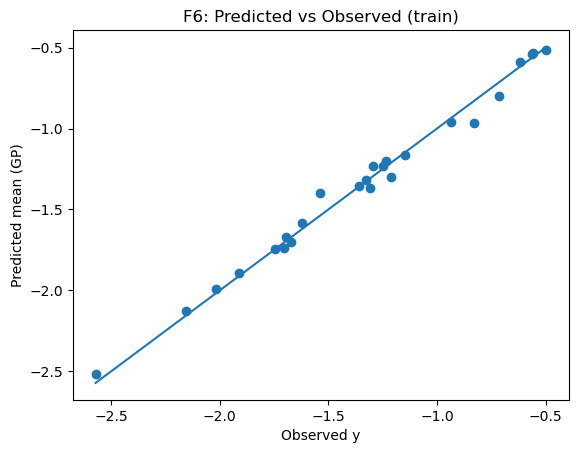

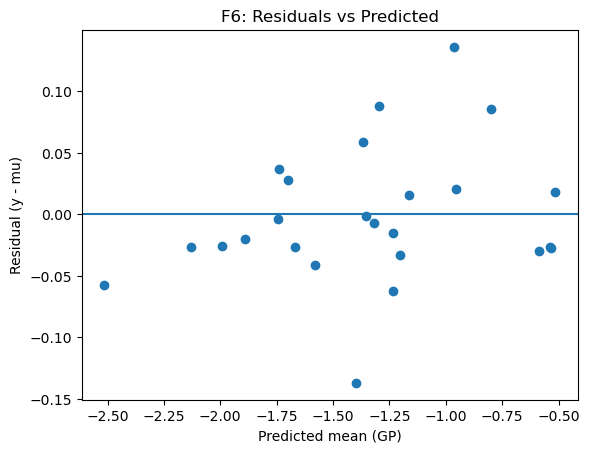

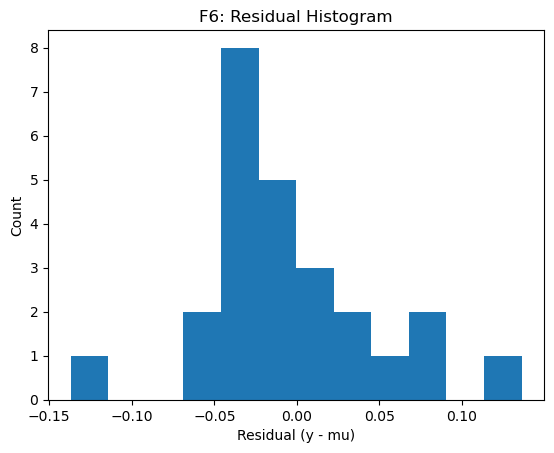

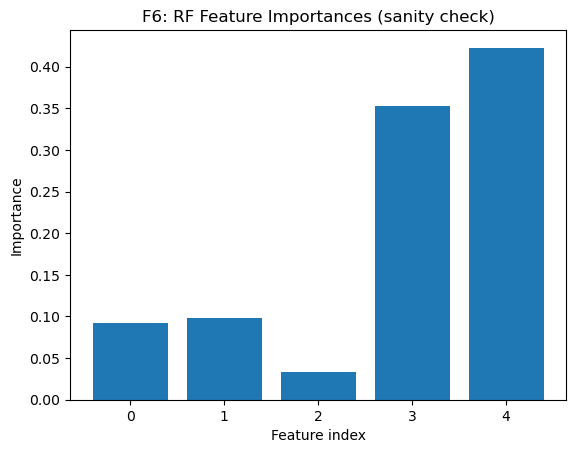

C:\Users\elena\AppData\Local\Temp\ipykernel_28352\985564105.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([X[:, j] for j in range(X.shape[1])], labels=[f"x{j+1}" for j in range(X.shape[1])])


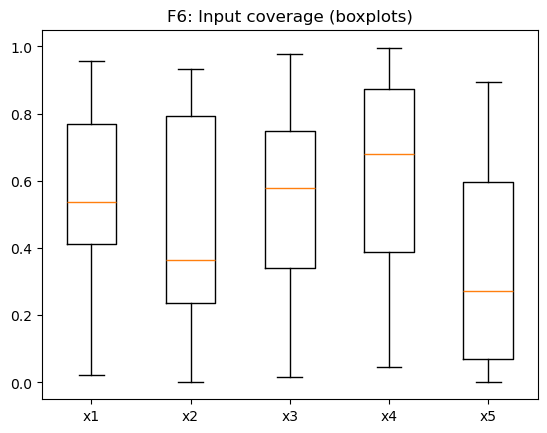

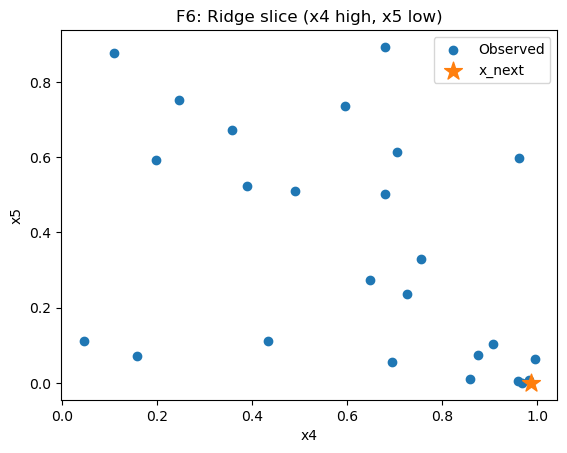

In [6]:
# ============================================================
# 4) DIAGNOSTICS
# ============================================================

# 4.1 Predicted mean vs observed (train)
plt.figure()
plt.scatter(y, mu_train)
mn = float(min(y.min(), mu_train.min()))
mx = float(max(y.max(), mu_train.max()))
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Observed y")
plt.ylabel("Predicted mean (GP)")
plt.title("F6: Predicted vs Observed (train)")
plt.show()

# 4.2 Residuals
resid = y - mu_train
plt.figure()
plt.scatter(mu_train, resid)
plt.axhline(0)
plt.xlabel("Predicted mean (GP)")
plt.ylabel("Residual (y - mu)")
plt.title("F6: Residuals vs Predicted")
plt.show()

plt.figure()
plt.hist(resid, bins=12)
plt.xlabel("Residual (y - mu)")
plt.ylabel("Count")
plt.title("F6: Residual Histogram")
plt.show()

# 4.3 Feature importance sanity check (Random Forest)
importances = rf.feature_importances_
plt.figure()
plt.bar(range(X.shape[1]), importances)
plt.xlabel("Feature index")
plt.ylabel("Importance")
plt.title("F6: RF Feature Importances (sanity check)")
plt.show()

# 4.4 Coverage / “not stuck in one region”
plt.figure()
plt.boxplot([X[:, j] for j in range(X.shape[1])], labels=[f"x{j+1}" for j in range(X.shape[1])])
plt.ylim(-0.05, 1.05)
plt.title("F6: Input coverage (boxplots)")
plt.show()

# 4.5 Visual ridge slice: x4 vs x5 with selected next point
plt.figure()
plt.scatter(X[:, 3], X[:, 4], label="Observed")
plt.scatter([x_next[3]], [x_next[4]], marker="*", s=180, label="x_next")
plt.xlabel("x4")
plt.ylabel("x5")
plt.title("F6: Ridge slice (x4 high, x5 low)")
plt.legend()
plt.show()


In [7]:
# ============================================================
# 5) OUTPUT (the one line you submit)
# ============================================================
# Print as one clean line (copy/paste)
print("\nSUBMIT THIS X (one row, 5 values):")
print(" ".join([f"{v:.8f}" for v in x_next]))



SUBMIT THIS X (one row, 5 values):
0.45805854 0.38134890 0.48935920 0.98664159 0.00040518
